In [1]:
import pandas as pd 
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.makedirs("Read_sex_DEG_df/", exist_ok=True)

In [3]:
sex_res_df = pd.read_csv('Read_Supplemental_Data_12_sex.csv', index_col = 0)
sex_res_df.head()

# use q-value of 0.05
sex_res_df = sex_res_df[sex_res_df['q_val'] < 0.05]

In [4]:
Counter(sex_res_df.cellType)

Counter({'Ventricular_Cardiomyocytes': 139,
         'Fibroblast': 37,
         'Endothelium': 29,
         'Myeloid': 28,
         'Lymphocyte': 25,
         'Adipocytes': 25,
         'Perivascular': 22,
         'Neuron': 12})

In [5]:
# create consistent cell type

sex_res_df['consistent_cell_type'] = sex_res_df['cellType'].map(
    {"Ventricular_Cardiomyocytes": "Cardiomyocyte",
    "Endothelium": "Endothelial",
     "Adipocytes": "Adipocyte",
     "Myeloid": "Myeloid",
    "Lymphocyte": "Lymphoid",
    "Lymphatic_Endothelium": "LEC",
    "Neuron": "Neuronal",
    "Mast_Cell": "Mast",
    "Perivascular": "Pericyte",
    "Fibroblast": "Fibroblast"}
)

In [6]:
Counter(sex_res_df.consistent_cell_type)

Counter({'Cardiomyocyte': 139,
         'Fibroblast': 37,
         'Endothelial': 29,
         'Myeloid': 28,
         'Lymphoid': 25,
         'Adipocyte': 25,
         'Pericyte': 22,
         'Neuronal': 12})

In [7]:
#sex_res_df.loc[sex_res_df['consistent_cell_type'] == "Myeloid",]

In [8]:
sex_res_df

,gene,coefficientValue,q_val,pval,cellType,Effect_Magnitude,Effect_Direction,consistent_cell_type
1,KDM5D,4.657709,4.120000e-42,2.720000e-45,Endothelium,4.657709,Positive,Endothelial
2,UTY,4.630136,9.950000e-58,4.700000e-61,Endothelium,4.630136,Positive,Endothelial
3,ZFY,4.573562,2.500000e-37,1.890000e-40,Endothelium,4.573562,Positive,Endothelial
4,DDX3Y,4.477158,6.710000e-70,6.340000e-74,Endothelium,4.477158,Positive,Endothelial
5,EIF1AY,4.419745,3.570000e-46,2.020000e-49,Endothelium,4.419745,Positive,Endothelial
...,...,...,...,...,...,...,...,...
68127,KAT6A,0.249494,2.073060e-04,2.650000e-07,Adipocytes,0.249494,Positive,Adipocyte
68162,ALG13,-0.244656,1.512408e-02,3.430000e-05,Adipocytes,0.244656,Negative,Adipocyte
68381,HM13,0.221590,6.926674e-03,1.080000e-05,Adipocytes,0.221590,Positive,Adipocyte
68515,YTHDF3,-0.206771,3.805477e-02,1.241150e-04,Adipocytes,0.206771,Negative,Adipocyte


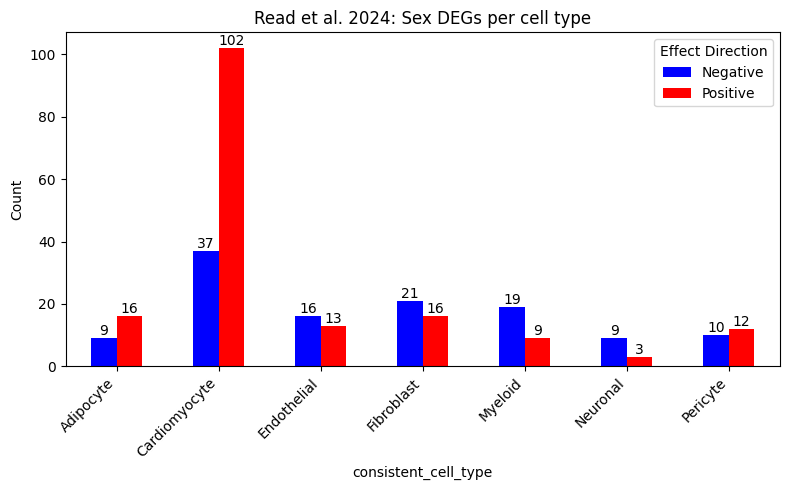

In [9]:
# get counts of DEGs
counts = sex_res_df.groupby(["consistent_cell_type", "Effect_Direction"]).size().reset_index(name="count")

# change order for x-axis
custom_order = ["Adipocyte", "Cardiomyocyte", "Endothelial", "Fibroblast", "Myeloid", "Neuronal", "Pericyte"]
counts["consistent_cell_type"] = pd.Categorical(
    counts["consistent_cell_type"],
    categories=custom_order,
    ordered=True
)

# pivot long
pivot_counts = counts.pivot(index="consistent_cell_type", columns="Effect_Direction", values="count").fillna(0)
pivot_counts = pivot_counts.reindex(custom_order)

# make barplot
ax = pivot_counts.plot(
    kind="bar",
    figsize=(8,5),
    color={"Positive": "red", "Negative": "blue"}
)

for container in ax.containers:
    ax.bar_label(container, label_type="edge")

plt.ylabel("Count")
plt.title("Read et al. 2024: Sex DEGs per cell type")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Effect Direction")
plt.tight_layout()
plt.show()

In [11]:
unique_cell_types = sex_res_df.consistent_cell_type.unique()
unique_cell_types

array(['Endothelial', 'Fibroblast', 'Lymphoid', 'Myeloid', 'Pericyte',
       'Cardiomyocyte', 'Neuronal', 'Adipocyte'], dtype=object)

In [13]:
for cell_type in unique_cell_types:
    cell_type_res_df = sex_res_df[sex_res_df['consistent_cell_type'] == cell_type]
    cell_type_res_df.to_csv("Read_sex_DEG_df/" + cell_type + "_DEG.csv")
    print(cell_type)

Endothelial
Fibroblast
Lymphoid
Myeloid
Pericyte
Cardiomyocyte
Neuronal
Adipocyte
